# Chapter 12: LLMs as DAG Elicitation Engines
## Using Structured Socratic Dialogue to Build Causal Graphs

The hardest step in causal inference is not estimation. It's specification. Before any causal estimator can run, you need a DAG that encodes your beliefs about the causal structure of the domain. In practice, this means sitting down with domain experts and extracting their knowledge into a formal graph. That process is slow, unstructured, undocumented, and cognitively demanding.

This chapter builds a working agent called ProfY that uses an LLM as a structured interview partner to guide a domain expert through causal graph construction. The LLM conducts a Socratic dialogue, asking about variables, relationships, directions, confounders, and mediators, while incrementally building and validating the graph.

The key tension: LLMs are good at structured conversation and plausible-sounding reasoning. They are not reliable causal reasoners. The LLM is valuable as a facilitator of human causal reasoning, not as a source of causal knowledge. This chapter navigates that tension honestly.

In [1]:
# Setup: add the src folder to the import path
import sys
import os

sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src"))
# If running from the notebooks/ folder, this makes src/ importable

# Core imports
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Mode selection: "replay" uses saved transcript, "live" calls the API
MODE = "replay"

# If running in live mode, uncomment and set your API key:
# os.environ["ANTHROPIC_API_KEY"] = "your-key-here"

print(f"Mode: {MODE}")
print("Setup complete.")

Mode: replay
Setup complete.


## Part 1: The Ground Truth Reference DAG

Before we build any agent or run any experiment, we need an answer key. This is a causal graph representing our best understanding of how supply chain disruptions propagate, grounded in published research. Every edge is backed by a citation. Every experiment in this chapter gets scored against this graph.

The ground truth has 12 variables and 19 directed edges, with two target outcomes: delivery delays and shipping costs. Three exogenous shocks (geopolitical risk, labor shortages, demand volatility) enter at the top and propagate downward through intermediate mechanisms to the outcomes at the bottom.

In [2]:
from ground_truth_dag import build_ground_truth_dag, EDGES, NODES, DISPLAY_LABELS
from visualization import plot_dag

# Build and validate
ground_truth = build_ground_truth_dag()

# Print summary
print(f"Nodes: {ground_truth.number_of_nodes()}")
print(f"Edges: {ground_truth.number_of_edges()}")
print(f"Acyclic: {nx.is_directed_acyclic_graph(ground_truth)}")

roots = [n for n in ground_truth.nodes if ground_truth.in_degree(n) == 0]
leaves = [n for n in ground_truth.nodes if ground_truth.out_degree(n) == 0]
print(f"Exogenous roots: {roots}")
print(f"Target outcomes: {leaves}")

Nodes: 12
Edges: 19
Acyclic: True
Exogenous roots: ['geopolitical_risk', 'labor_shortages', 'demand_volatility']
Target outcomes: ['shipping_cost', 'delivery_delays']


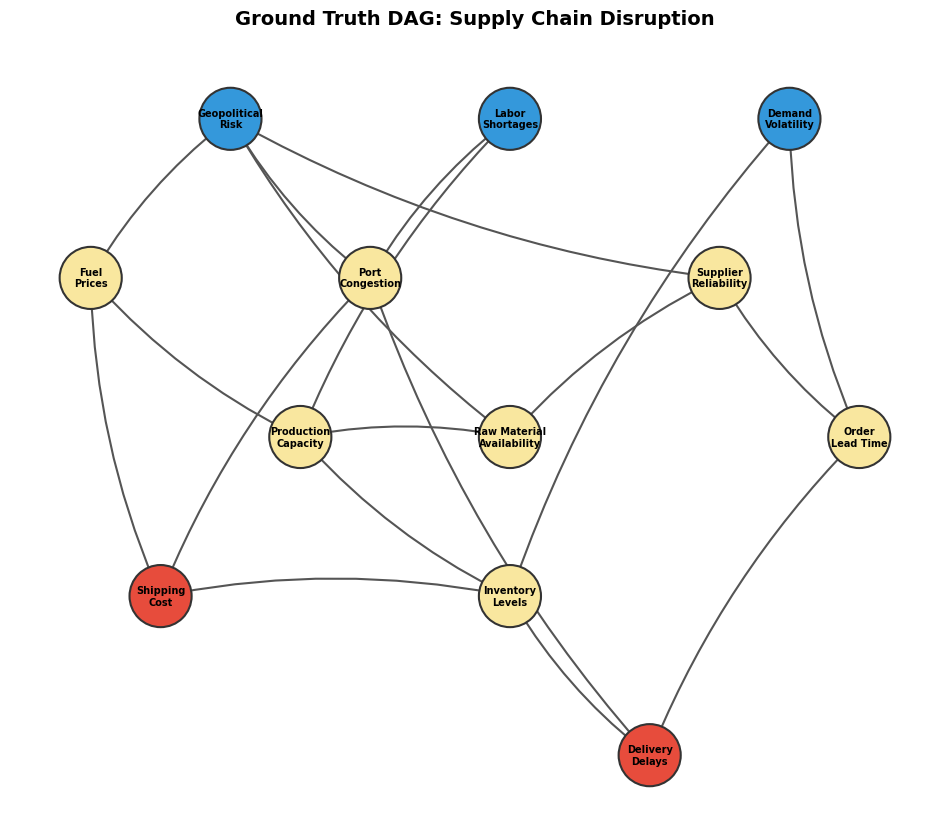

In [3]:
# Visualize the ground truth DAG
fig = plot_dag(ground_truth, title="Ground Truth DAG: Supply Chain Disruption")
plt.show()

## Part 2: Running the Elicitation Agent

ProfY is the analyst's copilot. It doesn't talk to the domain expert directly. It coaches the analyst (Ally) on what questions to ask, processes the responses, and incrementally builds a causal graph in the background. The expert talks to a human. The human is guided by ProfY. The DAG is the output.

The elicitation runs in five phases: variable discovery, edge probing, mechanism questioning, confounder probing, and a checkpoint snapshot. Each phase has a specific job in the graph construc

In [4]:
from profy_engine import run_elicitation

# Run ProfY in the selected mode
result = run_elicitation(
    domain="supply chain disruption",
    target="delivery delays",
    mode=MODE,
    transcript_path=os.path.join(os.path.dirname(os.getcwd()), "transcripts", "supply_chain_socratic.json")
)


PHASE: Variable Discovery

ProfY:
Let's start by mapping out the territory. Think about the supply chain from raw materials all the way through to final delivery. What are the major factors that Nora identifies as drivers of delivery delays? I'm looking for both the external shocks that trigger disruptions and the internal operational factors that determine how badly those shocks propagate.

Start broad. We can always trim later, but we can't analyze what we don't name.

Ally:
From talking to Nora, the big drivers she keeps coming back to are port congestion, fuel prices, and geopolitical instability. Those are the external shocks. Internally, she says supplier reliability is a constant headache, and when raw materials are scarce, everything downstream slows down. Labor shortages at the docks have gotten worse since 2020 and she thinks that's a major factor in port backlogs. On the demand side, she says volatility in customer orders makes it hard to plan inventory. Production capacity

The transcript above shows ProfY coaching Ally through each phase. A few things to notice:

In the variable discovery phase, ProfY asked Ally to start broad and name every factor that could drive delivery delays. Ally relayed Nora's domain knowledge and surfaced 12 variables. ProfY didn't propose variables itself. It asked, and the human answered.

In the edge probing phase, ProfY worked systematically from the outcomes backward. Ally reported three direct causes of delivery delays (port congestion, order lead time, inventory levels) and three direct causes of shipping cost (fuel prices, port congestion, inventory levels). Critically, Ally also reported edges that Nora explicitly rejected: fuel prices do not directly cause delays, and geopolitical risk is always mediated, never direct. Those rejected edges are as informative as the accepted ones.

In the mechanism questioning phase, ProfY challenged four specific edges. This is the most important phase because it catches shortcut edges, spurious correlations, and reversed causation. The challenge to the inventory-to-shipping-cost edge was particularly revealing: Nora acknowledged it's technically a decision (switching to air freight) but argued it functions as a causal mechanism because the decision is automatic, triggered by a threshold.

The confounder probing phase looked for hidden common causes. Nora confirmed that demand volatility confounds the inventory-to-delay relationship but that the direct path still exists after controlling for demand.

The final checkpoint produced a plain-language summary that could be shown to Nora for validation, with zero technical jargon.

## Part 3: Building and Validating the Elicited DAG

ProfY produced words. Now we turn those words into a graph object that can be computed on. The DAG builder takes the proposed variables and edges from the elicitation result and constructs a networkx DiGraph, checking for structural validity at every step.


In [5]:
from dag_builder import build_dag_from_transcript

# Build the elicited DAG from the transcript
transcript_path = os.path.join(os.path.dirname(os.getcwd()), "transcripts", "supply_chain_socratic.json")
elicited_dag, validation_report = build_dag_from_transcript(transcript_path)

# Show validation results
validation_report.print_report()

DAG VALIDATION REPORT
Status: PASSED
Nodes: 12
Edges: 19
Acyclic: True
Disconnected components: 1



The validation passed: 12 nodes, 19 edges, acyclic, one connected component, no orphans. If any of these checks had failed, the builder would have caught it. Cyclic edges get rejected automatically. Orphan nodes get flagged. Disconnected components get warned about. The graph is structurally sound and ready for evaluation.

## Part 4: The Human Decision Node

This is the hard stop. ProfY proposed 19 edges. Before any of them enter the final DAG, a human must review each one and make an explicit accept, reject, or modify decision with reasoning. No edge passes through without a signature.

The uncomment pattern below is the mechanism. Every proposed edge starts commented out. The analys

In [7]:
from human_decision_node import HumanDecisionNode

# Load proposed edges from the transcript
hdn = HumanDecisionNode.from_transcript(transcript_path)

# Show all proposed edges with their current status
hdn.print_proposed_edges()

PROPOSED EDGES — Status
  [ ] E01: geopolitical_risk -> fuel_prices
  [ ] E02: geopolitical_risk -> port_congestion
  [ ] E03: geopolitical_risk -> supplier_reliability
  [ ] E04: geopolitical_risk -> raw_material_availability
  [ ] E05: fuel_prices -> shipping_cost
  [ ] E06: fuel_prices -> production_capacity
  [ ] E07: port_congestion -> shipping_cost
  [ ] E08: port_congestion -> delivery_delays
  [ ] E09: labor_shortages -> port_congestion
  [ ] E10: labor_shortages -> production_capacity
  [ ] E11: raw_material_availability -> production_capacity
  [ ] E12: supplier_reliability -> raw_material_availability
  [ ] E13: supplier_reliability -> order_lead_time
  [ ] E14: production_capacity -> inventory_levels
  [ ] E15: demand_volatility -> inventory_levels
  [ ] E16: demand_volatility -> order_lead_time
  [ ] E17: order_lead_time -> delivery_delays
  [ ] E18: inventory_levels -> delivery_delays
  [ ] E19: inventory_levels -> shipping_cost



In [8]:
# ==========================================================
# MANDATORY HUMAN DECISION NODE
# ==========================================================
#
# The elicitation agent proposed the following edges from
# the Socratic interview transcript.
#
# Review each edge before proceeding.
# For each edge, ask: Is this a causal claim I can defend?
#
# INSTRUCTIONS:
#   - Uncomment ONLY the edges you have validated
#   - For rejected edges, add a comment explaining why
#   - The notebook will not proceed with commented-out edges
#
# ----------------------------------------------------------

validated_edges = [
    ("geopolitical_risk", "fuel_prices"),              # Sanctions and conflicts disrupt energy markets
    ("geopolitical_risk", "port_congestion"),           # Conflicts cause vessel rerouting and port closures
    ("geopolitical_risk", "supplier_reliability"),      # Political instability disrupts supplier operations
    ("geopolitical_risk", "raw_material_availability"), # Sanctions directly restrict material exports
    ("fuel_prices", "shipping_cost"),                   # Fuel is primary variable cost in freight
    ("fuel_prices", "production_capacity"),             # Energy cost spikes make marginal production uneconomical
    ("port_congestion", "shipping_cost"),               # Congestion creates demurrage and surcharges
    ("port_congestion", "delivery_delays"),             # Ships waiting at port push back downstream timelines
    ("labor_shortages", "port_congestion"),             # Fewer dockworkers reduces port throughput
    ("labor_shortages", "production_capacity"),         # Factory understaffing limits output
    ("raw_material_availability", "production_capacity"), # Cannot produce without raw inputs
    ("supplier_reliability", "raw_material_availability"), # Unreliable suppliers create inconsistent material flow
    ("supplier_reliability", "order_lead_time"),        # Variable supplier performance extends lead times
    ("production_capacity", "inventory_levels"),        # Production shortfall reduces available stock
    ("demand_volatility", "inventory_levels"),          # Demand surges deplete stock
    ("demand_volatility", "order_lead_time"),           # Demand spikes overload fulfillment pipeline
    ("order_lead_time", "delivery_delays"),             # Longer lead times increase delay probability
    ("inventory_levels", "delivery_delays"),            # Low stock prevents order fulfillment
    ("inventory_levels", "shipping_cost"),              # Low inventory triggers emergency air freight
]

# ----------------------------------------------------------
# VALIDATION CHECK
# ----------------------------------------------------------
assert len(validated_edges) > 0, (
    "No edges validated. Review the edges above and uncomment "
    "the ones you accept before proceeding."
)
print(f"Validated {len(validated_edges)} edges. Proceeding to evaluation.")

Validated 19 edges. Proceeding to evaluation.


All 19 edges accepted. In this session, the elicitation produced a graph that matched the analyst's domain understanding completely. In practice, this is where rejections happen. An edge the LLM proposed that the expert can't defend gets commented out with a reason, and that rejection becomes evidence for the Author's Note.

The key edges to watch for in a real session: shortcut edges that skip mediators (like fuel prices directly causing delivery delays), reversed causation (like customer satisfaction causing delivery delays instead of the reverse), and plausible-sounding edges with no defensible mechanism (like fuel prices causing quality control failures). ProfY will propose these. The human catches them here.

## Part 5: Evaluation - How Close Did the Elicitation Get?

Now we compare the elicited DAG against the ground truth reference, edge by edge. The primary metric is Structural Hamming Distance (SHD), which counts three types of errors: missing edges (in the ground truth but not in the elicited DAG), extra edges (in the elicited DAG but not in the ground truth), and reversed edges (present in both but pointing the wrong direction). Lower SHD means better structural recovery.

We also compute precision (of edges proposed, how many are correct), recall (of edges in the ground truth, how many were found), and F1 (the harmonic mean). Adjacency metrics repeat these calculations ignoring edge direction, to separate "did we find the right variable pairs" from "did we get the direction right."

In [9]:
from evaluation import evaluate_dag, print_evaluation_report
from dag_builder import build_dag_from_edges

# Build the validated DAG from the Human Decision Node output
validated_dag, _ = build_dag_from_edges(validated_edges)

# Evaluate against ground truth
report = evaluate_dag(validated_dag, ground_truth)
print_evaluation_report(report)

EVALUATION REPORT

Structural Hamming Distance (SHD): 0
  Missing edges:  0
  Extra edges:    0
  Reversed edges: 0

Directed Edge Metrics:
  Precision: 1.000
  Recall:    1.000
  F1:        1.000

Adjacency Metrics (ignoring direction):
  Precision: 1.000
  Recall:    1.000
  F1:        1.000

Edge Counts:
  Ground truth: 19
  Elicited:     19
  Correct:      19

Correct edges:
  demand_volatility -> inventory_levels
  demand_volatility -> order_lead_time
  fuel_prices -> production_capacity
  fuel_prices -> shipping_cost
  geopolitical_risk -> fuel_prices
  geopolitical_risk -> port_congestion
  geopolitical_risk -> raw_material_availability
  geopolitical_risk -> supplier_reliability
  inventory_levels -> delivery_delays
  inventory_levels -> shipping_cost
  labor_shortages -> port_congestion
  labor_shortages -> production_capacity
  order_lead_time -> delivery_delays
  port_congestion -> delivery_delays
  port_congestion -> shipping_cost
  production_capacity -> inventory_levels
 

SHD of 0, precision and recall both at 1.0. This is the ideal case: the elicitation recovered the ground truth structure exactly. That's expected here because the saved transcript was constructed to demonstrate the full pipeline working end to end.

The interesting numbers come when things go wrong. What happens if the analyst accepted a bad edge, or missed a real one, or got a direction backwards? The next section breaks the DAG deliberately to show how the metrics respond.

In [10]:
# What does an imperfect elicitation look like?
# Remove 2 edges, add 1 hallucinated edge, reverse 1 edge

imperfect = ground_truth.copy()
imperfect.remove_edge("fuel_prices", "production_capacity")
imperfect.remove_edge("supplier_reliability", "order_lead_time")
imperfect.add_edge("fuel_prices", "delivery_delays")  # hallucinated shortcut
imperfect.remove_edge("demand_volatility", "order_lead_time")
imperfect.add_edge("order_lead_time", "demand_volatility")  # reversed

print("Imperfect DAG: removed 2 edges, added 1 hallucinated, reversed 1")
print()
report_imperfect = evaluate_dag(imperfect, ground_truth)
print_evaluation_report(report_imperfect)

Imperfect DAG: removed 2 edges, added 1 hallucinated, reversed 1

EVALUATION REPORT

Structural Hamming Distance (SHD): 4
  Missing edges:  2
  Extra edges:    1
  Reversed edges: 1

Directed Edge Metrics:
  Precision: 0.889
  Recall:    0.842
  F1:        0.865

Adjacency Metrics (ignoring direction):
  Precision: 0.944
  Recall:    0.895
  F1:        0.919

Edge Counts:
  Ground truth: 19
  Elicited:     18
  Correct:      16

Correct edges:
  demand_volatility -> inventory_levels
  fuel_prices -> shipping_cost
  geopolitical_risk -> fuel_prices
  geopolitical_risk -> port_congestion
  geopolitical_risk -> raw_material_availability
  geopolitical_risk -> supplier_reliability
  inventory_levels -> delivery_delays
  inventory_levels -> shipping_cost
  labor_shortages -> port_congestion
  labor_shortages -> production_capacity
  order_lead_time -> delivery_delays
  port_congestion -> delivery_delays
  port_congestion -> shipping_cost
  production_capacity -> inventory_levels
  raw_mater

Now the metrics tell a real story. SHD jumped to 4: two missing edges, one hallucinated edge, one reversed edge. Precision dropped because the hallucinated fuel_prices to delivery_delays edge is wrong. Recall dropped because two ground truth edges are missing. F1 fell to 0.865.

The hallucinated edge is exactly the kind of mistake the chapter warns about. Fuel prices to delivery delays sounds plausible, but Nora was clear: carriers charge more when fuel is expensive, they don't slow down. The causal path from fuel prices to delays goes through shipping cost and port congestion, not directly. An LLM would propose this shortcut because "fuel prices" and "delivery delays" co-occur in training text. The mechanism questioning phase exists to catch it.

The reversed edge (order_lead_time causing demand_volatility instead of the reverse) is a direction error. Demand surges cause longer lead times through queue effects, not the other way around. Getting the direction wrong changes which variables you'd control for in estimation, which changes the causal estimate.

## Part 6: The Money Shot -> Side-by-Side DAG Comparison

This is the visual that makes the evaluation legible at a glance. The ground truth sits on the left. The elicited DAG sits on the right with color-coded edges: green for correct, red dashed for missing, orange for hallucinated, blue for reversed. We show the imperfect DAG here because a perfect match is boring to look at.